## Quantum Teleportation

Quantum teleportation transfers **quantum information** from one qubit to another. It's often compared to copy-paste, but that comparison doesn't quite hold up.

### Why You Can't Just "Copy" a Qubit

In a classical computer, copying information is straightforward: read the state of the bit you want to copy, then set another bit to match. This doesn't work for qubits, because *measuring* a qubit to read its state collapses it — the act of observation destroys the very quantum state you were trying to transfer. So teleportation isn't copying; it's a genuine **transfer** of state from one qubit to another, and the original qubit no longer holds that state afterward.

### The Setup

Quantum teleportation involves **three qubits** and two participants:

- One qubit holds an **unknown quantum state** that needs to be transferred.
- The sender and receiver each hold one half of a **shared entangled Bell pair** (it doesn't matter which half goes to which person, since the Bell state is symmetric).
- Because the pair is entangled, the two participants can share quantum information between their qubits even if they're arbitrarily far apart.

### Step 1: Bell State Measurement

The sender performs a Bell state measurement on **two qubits**: the original qubit holding the unknown state, and their half of the shared entangled pair. This is done by applying a CNOT and a Hadamard gate, then measuring both qubits.

This is a **partial measurement** of the overall three-qubit system, and it produces **two classical bits** of information. The sender then transmits these two bits to the receiver using any classical communication channel (a text message, for example).

### Step 2: Recovery Operation

Using the two classical bits from the sender's measurement, the receiver applies **one of four transformations** to their own qubit to fully recover the teleported state:

| Sender's Measurement (shared qubit, original qubit) | Recovery Operation |
|:---:|:---|
| `0`, `0` | $I$ (identity — do nothing) |
| `1`, `0` | $X$ |
| `0`, `1` | $Z$ |
| `1`, `1` | $X$ then $Z$ |

The mathematical reasoning behind why these four operations correctly recover the state involves a deeper dive into the underlying algebra, beyond the scope of an introductory overview — the Qiskit textbook's page on quantum teleportation is a good resource for that derivation.

Once the correct operation is applied, the receiver's qubit is now in the exact state that the original qubit started in — the state has been **teleported**, not duplicated. The original qubit was altered by the measurement step and no longer holds that state.

### Why This Doesn't Break the Speed of Light

Since entanglement produces instantaneous correlations, it might look like information was sent faster than light. It wasn't:

- The receiver can't recover anything meaningful until they receive the sender's **classical** measurement results.
- If the receiver applied a recovery operation *before* getting those two bits, the outcome would be random and useless.
- No information is transferred until the classical bits physically arrive — which is limited by the speed of ordinary communication, not instantaneous.

### Security

Each of the four possible measurement outcomes on the sender's side occurs with **equal probability**. This means:

- If an eavesdropper intercepts the two classical bits sent between participants, those bits look completely random and reveal nothing about the quantum state being transferred.
- Recovering the teleported state requires **both** the physical qubit on the receiver's end *and* the two classical bits — neither alone is sufficient.

### Relationship to Superdense Coding

Quantum teleportation is a close relative of superdense coding, and both rely on a pre-shared entangled pair — but they move information in opposite directions:

- **Superdense coding**: transfers *two classical bits* by encoding them onto a qubit and physically sending that one qubit.
- **Quantum teleportation**: transfers *one qubit's quantum state* by physically sending *two classical bits*.

Like superdense coding, quantum teleportation was discovered and experimentally demonstrated in the mid-1990s, making it a relatively young addition to the quantum algorithm toolkit. The simple version described here can also be extended to teleport more complex quantum systems.

## Quantum Teleportation: The Math Behind the Recovery Operations

### Setup

Let the state to be teleported be an arbitrary single-qubit state on qubit $q_0$:

$$
\vert\psi\rangle_{q_0} = \alpha\vert0\rangle + \beta\vert1\rangle
$$

Alice holds $q_0$ and $q_1$; Bob holds $q_2$. Qubits $q_1$ and $q_2$ start out as a shared Bell pair:

$$
\vert\Phi^+\rangle_{q_1 q_2} = \frac{\vert00\rangle + \vert11\rangle}{\sqrt{2}}
$$

The full three-qubit initial state (written as $q_0 q_1 q_2$) is:

$$
\vert\psi\rangle_{q_0} \otimes \vert\Phi^+\rangle_{q_1 q_2}
= \frac{1}{\sqrt{2}}\Big[\alpha\vert000\rangle + \alpha\vert011\rangle + \beta\vert100\rangle + \beta\vert111\rangle\Big]
$$

### Step 1: Alice applies CNOT ($q_0 \to q_1$)

CNOT flips $q_1$ whenever $q_0 = 1$:

$$
\frac{1}{\sqrt{2}}\Big[\alpha\vert000\rangle + \alpha\vert011\rangle + \beta\vert110\rangle + \beta\vert101\rangle\Big]
$$

### Step 2: Alice applies Hadamard to $q_0$

Using $H\vert0\rangle = \frac{1}{\sqrt2}(\vert0\rangle+\vert1\rangle)$ and $H\vert1\rangle = \frac{1}{\sqrt2}(\vert0\rangle-\vert1\rangle)$, and expanding each term:

$$
\frac{1}{2}\Big[
\alpha(\vert000\rangle+\vert100\rangle)
+ \alpha(\vert011\rangle+\vert111\rangle)
+ \beta(\vert010\rangle-\vert110\rangle)
+ \beta(\vert001\rangle-\vert101\rangle)
\Big]
$$

### Step 3: Group terms by Alice's two measurement outcomes

Regroup the eight terms according to the values of $(q_0, q_1)$, factoring out Bob's qubit $q_2$ in each group:

$$
\frac{1}{2}\Big[
\vert00\rangle_{q_0q_1}(\alpha\vert0\rangle+\beta\vert1\rangle)_{q_2}
+ \vert01\rangle_{q_0q_1}(\beta\vert0\rangle+\alpha\vert1\rangle)_{q_2}
$$
$$
+\ \vert10\rangle_{q_0q_1}(\alpha\vert0\rangle-\beta\vert1\rangle)_{q_2}
+ \vert11\rangle_{q_0q_1}(-\beta\vert0\rangle+\alpha\vert1\rangle)_{q_2}
\Big]
$$

This is the key result: whichever outcome Alice measures on $(q_0, q_1)$, Bob's qubit $q_2$ collapses into a state that is **exactly $\vert\psi\rangle$ acted on by one of the four Pauli operators** — with equal $1/4$ probability for each outcome (each term has equal weight $\tfrac12$, normalized to probability $\tfrac14$).

### Step 4: Identify Bob's correction for each outcome

Compare each resulting state on $q_2$ to $\vert\psi\rangle = \alpha\vert0\rangle+\beta\vert1\rangle$ under the Pauli operators:

$$
X\vert\psi\rangle = \beta\vert0\rangle+\alpha\vert1\rangle
\qquad
Z\vert\psi\rangle = \alpha\vert0\rangle-\beta\vert1\rangle
\qquad
XZ\vert\psi\rangle = -\beta\vert0\rangle+\alpha\vert1\rangle
$$

Matching these against the four grouped terms above:

| Alice measures $(q_0,q_1)$ | Bob's qubit collapses to | Correction Bob applies |
|:---:|:---|:---:|
| $00$ | $\alpha\vert0\rangle+\beta\vert1\rangle = \vert\psi\rangle$ | $I$ |
| $01$ | $\beta\vert0\rangle+\alpha\vert1\rangle = X\vert\psi\rangle$ | $X$ |
| $10$ | $\alpha\vert0\rangle-\beta\vert1\rangle = Z\vert\psi\rangle$ | $Z$ |
| $11$ | $-\beta\vert0\rangle+\alpha\vert1\rangle = XZ\vert\psi\rangle$ | $Z$ then $X$ |

In every case, applying the matching correction returns $q_2$ to exactly $\vert\psi\rangle$ — the original unknown state, now fully recovered on Bob's qubit.

### Compact form

The whole protocol can be summarized as: measure $q_0 \to m_0$ and $q_1 \to m_1$, then Bob applies

$$
X^{m_1} Z^{m_0}
$$

to his qubit, where the exponent means "apply the gate if the bit is $1$, otherwise do nothing." This single expression reproduces all four rows of the table above.

### Why This Works Without Violating Relativity

Because each of the four outcomes is **equally likely** ($\tfrac14$ probability each), and Bob's qubit's *reduced density matrix* — averaged over all of Alice's possible outcomes — is exactly the **maximally mixed state** $\tfrac{I}{2}$, completely independent of $\alpha$ and $\beta$. This means that before Bob learns Alice's classical measurement result, his qubit carries *zero information* about $\vert\psi\rangle$ — it only becomes recoverable once the classical bits $(m_0, m_1)$ arrive through an ordinary (light-speed-limited) channel.

In [44]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

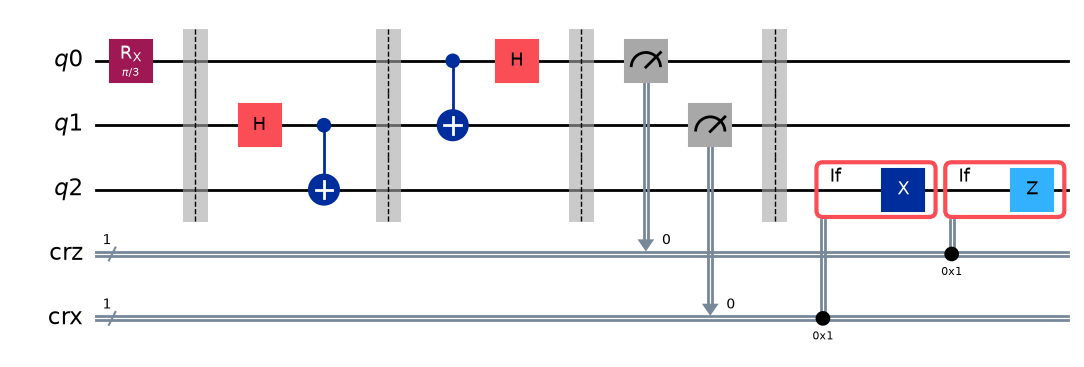

In [45]:
# initialize 3-qubit circuit with named registers.
q0 = QuantumRegister(1, name="q0")  # Source's qubit to teleport.
q1 = QuantumRegister(1, name="q1")  # Qubit sent to source (half of Bell state pair).
q2 = QuantumRegister(1, name="q2")  # Destination's qubit (half of Bell state pair).

crz = ClassicalRegister(1, name="crz")  # Source's measurement of her source qubit.
crx = ClassicalRegister(1, name="crx")  # Source's measurement of middle qubit (half of Bell state pair).

circuit = QuantumCircuit(q0, q1, q2, crz, crx)

# Initialize Source's qubit (quantum state to teleport).
circuit.rx(pi/3, q0)
circuit.barrier()

# Create Bell State pair.
circuit.h(q1)
circuit.cx(q1, q2)
circuit.barrier()

# Source performs Bell state measurement.
circuit.cx(q0, q1)
circuit.h(q0)
circuit.barrier()

circuit.measure(q0, crz)
circuit.measure(q1, crx)
circuit.barrier()


# Destination performs qubit based correction on results.
with circuit.if_test((crx, 1)):   # Apply X gate if cr-x is 1.
    circuit.x(q2)
with circuit.if_test((crz, 1)):   # Apply Z gate if cr-z is 1.
    circuit.z(q2)

circuit.draw(output='mpl')

In [46]:
simulator = AerSimulator(method='statevector')

circuit.save_statevector()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

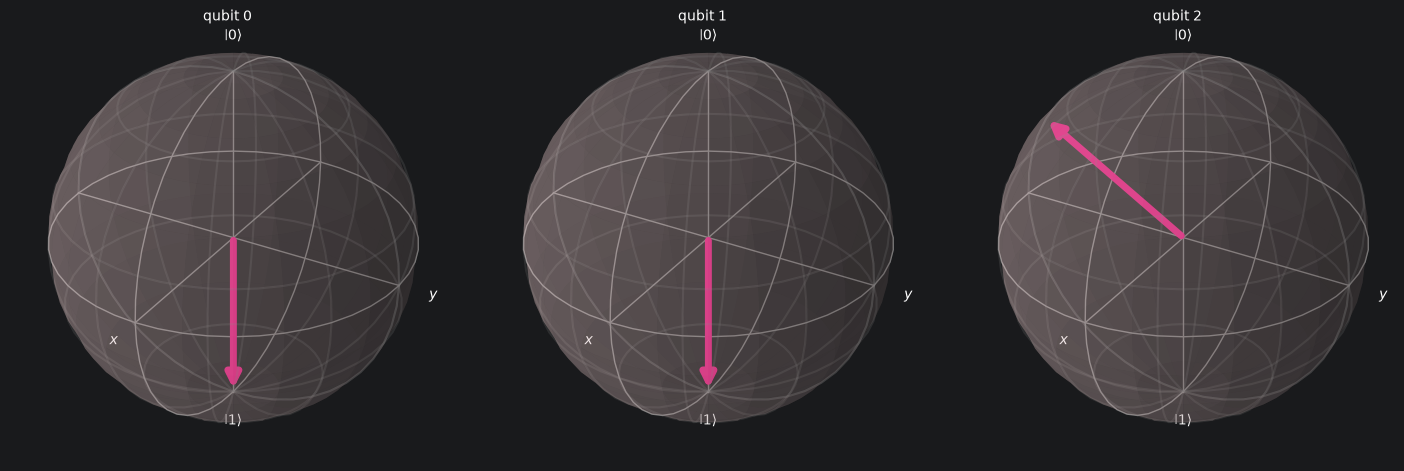

In [47]:
plot_bloch_multivector(statevector)

## Analysis: Bloch Sphere Visualization of Teleportation Mid-Circuit State

### What's Being Shown

Qiskit's statevector simulator lets us visualize the individual state of each of the three qubits on separate Bloch spheres at a given point in the circuit. Here, the snapshot is taken **after the Bell state measurement** on qubits `q0` (Source's original qubit) and `q1` (Source's half of the shared entangled pair) — but the classical corrections have already been applied to `q2` by this point.

### Qubits 0 and 1: Collapsed to a Random Basis State

Once Source performs her Bell state measurement, `q0` and `q1` are no longer in a superposition — they've **collapsed** into one of the four possible two-bit basis states ($00$, $01$, $10$, or $11$), each occurring with **equal $1/4$ probability**.

In this particular run:
- `q0` collapsed to $\vert0\rangle$
- `q1` collapsed to $\vert1\rangle$

This is exactly what the Bloch spheres show: both qubits point to a **pole** of their sphere ($\vert0\rangle$ or $\vert1\rangle$), rather than sitting in a superposition somewhere on the sphere's surface — a clear visual confirmation that measurement has occurred and the outcome is now classical.

### Qubit 2: Always the Teleported State

Regardless of which of the four random outcomes occurs for `q0` and `q1`, Destination's qubit (`q2`, shown on the far right) **always ends up in the exact state that Source's original qubit (`q0`) started in** — provided the correct classical correction ($X$ and/or $Z$, conditioned on the measurement results) has already been applied.

In this example, Source's qubit was initialized using an $R_X$ rotation gate, placing it into a specific superposition on the Bloch sphere (not aligned with a pole). Because that same superposition is what ultimately appears on `q2` at the end of the protocol, the third Bloch sphere shows a vector tilted away from the poles — matching the original $R_X$-rotated state, not $\vert0\rangle$ or $\vert1\rangle$.

### Confirming This Empirically

Re-running the simulation cell repeatedly produces a **different random outcome** for `q0` and `q1` on each run — their Bloch vectors will jump to different poles from run to run. However, `q2`'s Bloch vector **stays fixed** at the same tilted position every single time.

This is the empirical signature of successful teleportation:
- The **randomness** lives entirely in the intermediate measurement (`q0`, `q1`).
- The **teleported state** on `q2` is **deterministic** once the classical correction is applied — it doesn't depend on which of the four random outcomes occurred, because the correction step is specifically designed to undo whatever effect that particular outcome had on `q2`.

### Why This Matters

This visualization makes concrete something that can otherwise feel abstract: even though the *intermediate* classical information (which of the four Bell outcomes occurred) is random and reveals nothing on its own, the *combination* of that classical information with the correction operation reliably reconstructs the original quantum state — with no dependence on the random outcome in the final result.

## Analysis: The Deferred Measurement Principle

### The Problem: Instructions After Measurement

The teleportation circuit built so far measures qubits `q0` and `q1`, then applies **classically-conditioned gates** (the $X$ and $Z$ corrections) to `q2` afterward. Running additional gate instructions *after* a measurement isn't a problem for Qiskit's simulator — it handles this fine.

However, this pattern can be a real problem on **actual quantum hardware**. Many physical quantum computers — including current IBM quantum systems — don't support applying further instructions after a mid-circuit measurement has already occurred. If this circuit were submitted to run on real hardware in its current form, **the job would fail** outright.

### The Solution: Deferred Measurement

This is where the **deferred measurement principle** comes in — a foundational idea in quantum computing which states that **any measurement in a circuit can be postponed until the very end**, without changing the circuit's outcome.

The core idea: instead of measuring a qubit mid-circuit and then classically conditioning a later gate on that result, you can instead:

1. Replace the "measure, then classically apply a gate if the result is 1" pattern with a **controlled quantum gate**, using the not-yet-measured qubit directly as the control.
2. Push the actual measurement of that qubit to the end of the circuit.

Because a controlled gate conditioned on a qubit *before* measurement produces mathematically the same result as measuring first and classically applying the gate afterward, this substitution preserves the algorithm's correctness — while making the circuit compatible with hardware that disallows mid-circuit measurement followed by further instructions.

### Why This Matters for Teleportation Specifically

In the teleportation circuit, this means the classically-conditioned $X$ and $Z$ corrections on `q2` (previously triggered by measuring `q0` and `q1`) can instead be replaced with a **controlled-X (CNOT)** and a **controlled-Z**, using `q0` and `q1` directly as controls — with the measurements of all three qubits moved to occur only at the very end of the circuit.

This reformulation produces an equivalent circuit that's compatible with real quantum hardware, since it eliminates the need to execute any gate after a measurement has taken place.